# Projeto Sprint 10

## 1. - Introdução ao dataset

### 1.1 - Importação bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import graph_objects as go
import re

### 1.2 - Leitura dataset

In [3]:
# leitura arquivo csv
rest_data = pd.read_csv('../dataset/rest_data_us_upd.csv')

### 1.3 - Primeiras impressões

In [4]:
# descoberta primeiras linhas
rest_data.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [5]:
# descoberta informações gerais
rest_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   str   
 2   address      9651 non-null   str   
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   str   
 5   number       9651 non-null   int64 
dtypes: int64(2), object(1), str(3)
memory usage: 452.5+ KB


In [6]:
# descoberta detalhes
rest_data.describe()

,id,number
count,9651.000000,9651.000000
mean,16611.000000,43.695161
std,2786.148058,47.622874
min,11786.000000,1.000000
25%,14198.500000,14.000000
50%,16611.000000,27.000000
75%,19023.500000,46.000000
max,21436.000000,229.000000


O dataframe rest_data apresenta a nomeclatura de colunas dentro do padrão snake case.
Existe a necessidade de conversão no tipo de dado de suas colunas.
Foram constatados valores ausentes.

## 2. - Pré processamento de dados

### 2.1 - Ajuste nomenclatura colunas

In [7]:
# confirmação padrão snake_case
rest_data.columns = rest_data.columns.str.strip().str.lower().str.replace('object_', '')

### 2.2 - Ajuste colunas Object type

In [8]:
# coluna name
rest_data['name'] = rest_data['name'].str.strip().str.lower()

In [9]:
# coluna address
rest_data['address'] = rest_data['address'].str.strip().str.lower()

In [10]:
# coluna type
rest_data['type'] = rest_data['type'].str.strip().str.lower()

### 2.3 - Ajuste tipos de dados

In [11]:
# coluna chain
rest_data['chain'] = rest_data['chain'].astype('category')

In [12]:
# coluna type
rest_data['type'] = rest_data['type'].astype('category')

### 2.4 - Validação ausentes

In [13]:
# descoberta quantidade de valores ausentes
rest_data.isna().sum()

id         0
name       0
address    0
chain      3
type       0
number     0
dtype: int64

In [14]:
# descoberta linhas coluna chain NAN
nans_names = rest_data[rest_data['chain'].isna()]['name']
rest_data[rest_data['chain'].isna()]

,id,name,address,chain,type,number
7408,19194,taqueria los 3 carnales,5000 e whittier blvd,NaN,restaurant,14
7523,19309,jammin jimmy's pizza,1641 firestone blvd,NaN,pizza,1
8648,20434,the lexington theater,129 e 3rd st,NaN,restaurant,35


In [15]:
# descoberta se há repetições de nomes
rest_data[rest_data['name'].isin(nans_names)]

,id,name,address,chain,type,number
7408,19194,taqueria los 3 carnales,5000 e whittier blvd,NaN,restaurant,14
7523,19309,jammin jimmy's pizza,1641 firestone blvd,NaN,pizza,1
8648,20434,the lexington theater,129 e 3rd st,NaN,restaurant,35


In [16]:
# substituição valores ausentes
rest_data['chain'] = rest_data['chain'].fillna(False)

### 2.5 - Validação duplicados

In [17]:
# descoberta valores duplicados
rest_data.duplicated().sum()

np.int64(0)

In [18]:
# descoberta valores duplicados com base na coluna id
print(rest_data[['id', 'name']].duplicated().sum())
print(rest_data[['id', 'address']].duplicated().sum())
print(rest_data[['id', 'chain']].duplicated().sum())

0
0
0


## 3. - EDA

### 3.1 - Investigue as proporções de vários tipos de estabelecimentos. Construa um gráfico.


In [19]:
# agrupamento de dados
types = rest_data.groupby('type')['name'].count().reset_index().rename(columns={'type': 'type', 'name': 'quantity'})
types

,type,quantity
0,bakery,283
1,bar,292
2,cafe,435
3,fast food,1066
4,pizza,320
5,restaurant,7255


In [20]:
# criação coluna proporção
total = types['quantity'].sum()
types['proportion'] = (types['quantity'] / total) * 100
types

,type,quantity,proportion
0,bakery,283,2.932339
1,bar,292,3.025593
2,cafe,435,4.507305
3,fast food,1066,11.045488
4,pizza,320,3.315719
5,restaurant,7255,75.173557


In [21]:
# criação gráfico pizza
proportion_types_pizza = go.Figure(data=[go.Pie(labels=types['type'], values=types['quantity'])])
proportion_types_pizza.update_layout(
    title='Establishment types in LA',
    legend=dict(
        title='Types',
        x=1,
        y=0.5
    ),
    width=1000,
    height=500
)
proportion_types_pizza.show()

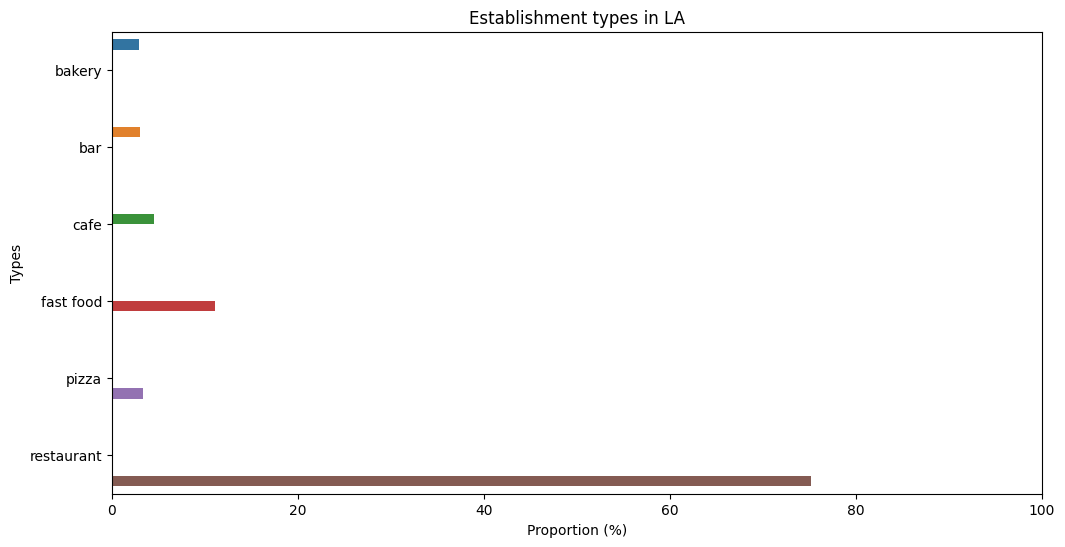

In [22]:
# construção gráfico de barras horizontal
plt.figure(figsize=(12,6))
sns.barplot(data=types, x='proportion', y='type', hue='type')
plt.title('Establishment types in LA')
plt.ylabel('Types')
plt.xlabel('Proportion (%)')
plt.xlim(0, 100)
plt.show()

Com grande maioria, os Restaurantes lideram os tipos de estabelecimentos em LA(75%).

Logo em seguida, Fast Foods (11%) e Cafés (4,5%)

Para os demais, ficam muito equiparados entre Pizzarias, Bares e Padarias (3%).

### 3.2 - Investigue as proporções de estabelecimentos de rede e não. Construa um gráfico.


In [23]:
# agrupamento dados
is_chain = rest_data.groupby('chain')['name'].count().reset_index().rename(columns={'chain': 'answers', 'name': 'quantity'})
is_chain

,answers,quantity
0,False,5975
1,True,3676


In [24]:
# criação coluna proportion
is_chain['proportion'] = (is_chain['quantity'] / total) * 100
is_chain

,answers,quantity,proportion
0,False,5975,61.910683
1,True,3676,38.089317


In [25]:
# criação gráfico pizza
proportion_chain_pizza = go.Figure(data=[go.Pie(labels=is_chain['answers'], values=is_chain['proportion'])])
proportion_chain_pizza
proportion_chain_pizza.update_layout(
    title='Is the Establishment part of a chain?',
    legend=dict(
        title='Answers',
        x=1,
        y=0.5
    ),
    width=1000,
    height=500
)
proportion_chain_pizza.show()

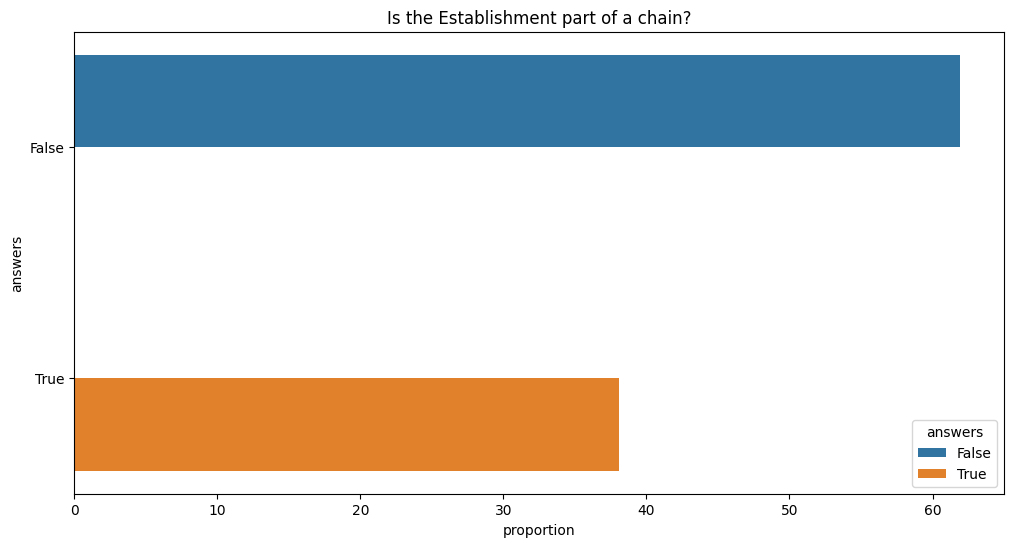

In [26]:
# criação gráfico barras horizontal
plt.figure(figsize=(12,6))
sns.barplot(data=is_chain, x='proportion', y='answers', hue='answers')
plt.title('Is the Establishment part of a chain?')
plt.show()

A maioria dos estabelecimentos listados pertencem não pertencem a uma rede (62% x 38%).

### 3.3 - Qual tipo de estabelecimento é típico para redes?

In [27]:
# filtro chain
chain_data = rest_data[rest_data['chain'] == True]
chain_data

,id,name,address,chain,type,number
8,11794,abc donuts,3027 n san fernando rd unit 103,True,fast food,1
10,11796,el pollo loco,5319 w sunset blvd,True,restaurant,38
11,11797,poong nyun bakery,928 s western ave ste 109,True,bakery,17
12,11798,emc restaurant group llc,3500 w 6th st ste 101,True,restaurant,133
14,11800,cuscatleca bakery,2501 w sunset blvd #a,True,bakery,26
...,...,...,...,...,...,...
9629,21415,jucuapa bakery,2810 james wood blvd,True,bakery,10
9636,21422,chipotle #3094,6719 la tijera blvd a-b,True,restaurant,47
9639,21425,mcdonald's,1800 s western ave,True,fast food,135
9648,21434,juicy wingz,6741 hollywood blvd,True,fast food,15


In [28]:
# agrupamento dados
chain_types = chain_data.groupby('type')['name'].count().reset_index().rename(columns={'type': 'type', 'name': 'quantity'})
chain_types

,type,quantity
0,bakery,283
1,bar,77
2,cafe,266
3,fast food,605
4,pizza,153
5,restaurant,2292


In [29]:
# criação coluna proporção
total_chain = chain_types['quantity'].sum()
chain_types['proportion'] = (chain_types['quantity'] / total_chain) * 100
chain_types

,type,quantity,proportion
0,bakery,283,7.698585
1,bar,77,2.094668
2,cafe,266,7.236126
3,fast food,605,16.458107
4,pizza,153,4.162133
5,restaurant,2292,62.350381


In [30]:
# criação gráfico pizza
chain_types_pizza = go.Figure(data=[go.Pie(labels=chain_types['type'], values=chain_types['proportion'])])
chain_types_pizza.update_layout(
    title='Establishments types in LA parts of a chain',
    legend=dict(
        title='Types',
        x=1,
        y=0.5
    ),
    width=1000,
    height=500
)
chain_types_pizza.show()

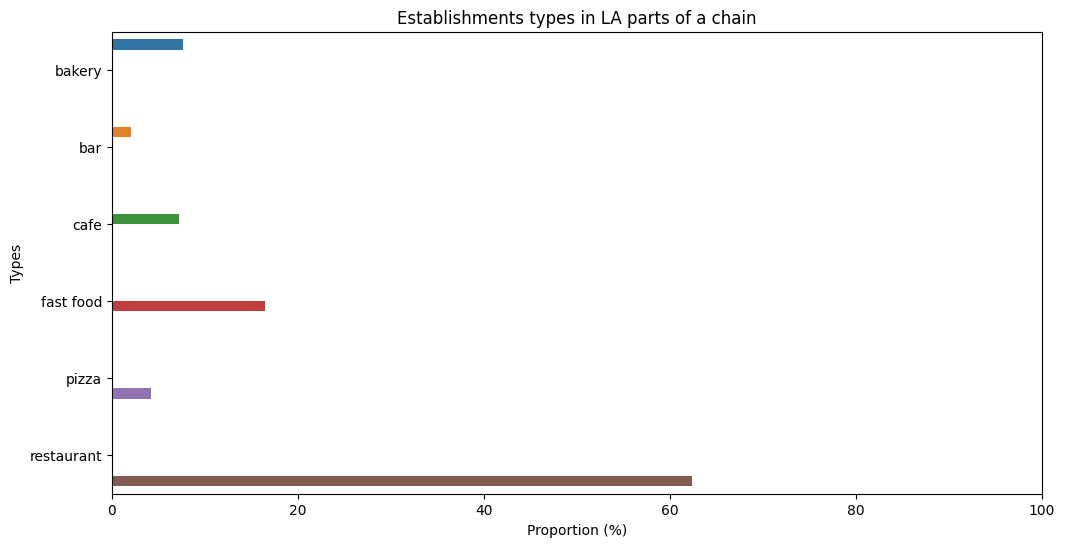

In [31]:
# criação gráfico barras horizontal
plt.figure(figsize=(12,6))
sns.barplot(data=chain_types, x='proportion', y='type', hue='type')
plt.title('Establishments types in LA parts of a chain')
plt.xlabel('Proportion (%)')
plt.ylabel('Types')
plt.xlim(0,100)
plt.show()

Com grande maioria, os Restaurantes lideram nos tipos de estabelecimentos parte de uma rede (62%).

Logo em seguida, Fast Foods (16.5%).

Após, equiparados Padarias e Cafés (7%).

Para os demais,  Pizzarias (4%) e Bares (2%).

### 3.4 - O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?

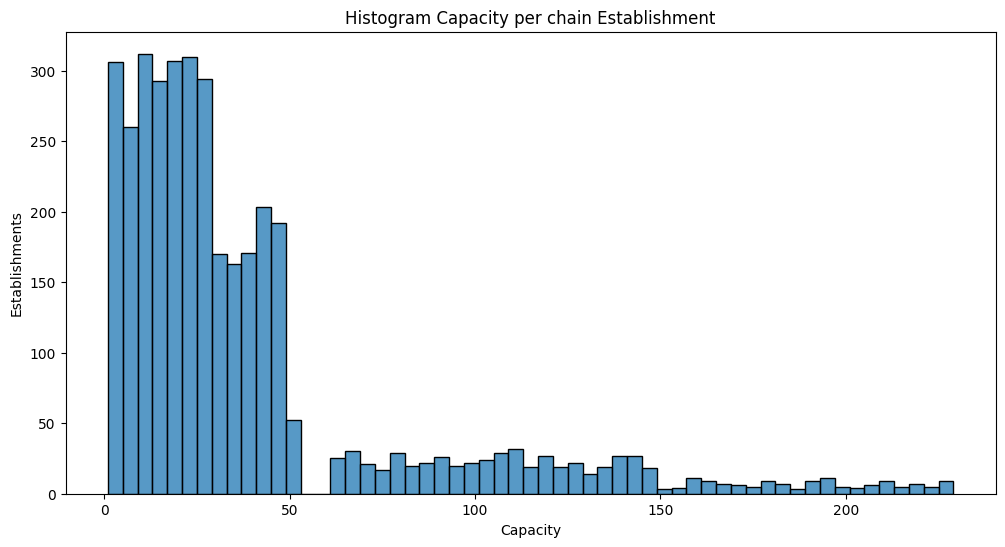

In [32]:
# criação gráfico dispersão
plt.figure(figsize=(12,6))
sns.histplot(data=chain_data['number'])
plt.title('Histogram Capacity per chain Establishment')
plt.xlabel('Capacity')
plt.ylabel('Establishments')
plt.show()

Estabelecimentos por rede podem ser caracterizados como muitos estabelecimentos com poucos assentos e poucos estabelecimentos com muitos assentos.

### 3.5 - Determine o número médio de assentos para cada tipo de restaurante. Em média, qual tipo de restaurante tem o maior número de assentos? Construa gráficos.

In [33]:
# filtro dados
is_restaurant = rest_data[rest_data['type'] == 'restaurant']
is_restaurant

,id,name,address,chain,type,number
1,11787,reilly's,100 world way 120,False,restaurant,9
3,11789,triniti echo park,1814 w sunset blvd,False,restaurant,22
4,11790,pollen,2100 echo park ave,False,restaurant,20
5,11791,the spot grill,10004 national blvd,False,restaurant,14
6,11792,cpk,100 world way 126,False,restaurant,100
...,...,...,...,...,...,...
9643,21429,divine dips,601 s los angeles st,False,restaurant,25
9645,21431,saint marc,10250 santa monica blvd 1025,False,restaurant,225
9646,21432,hall of justice,217 w temple ave,False,restaurant,122
9647,21433,fin-melrose,5750 melrose ave,False,restaurant,93


In [34]:
# agrupamento dados
sits_per_restaurant = rest_data.groupby('chain')['number'].mean().reset_index()
sits_per_restaurant

,chain,number
0,False,46.156653
1,True,39.694233


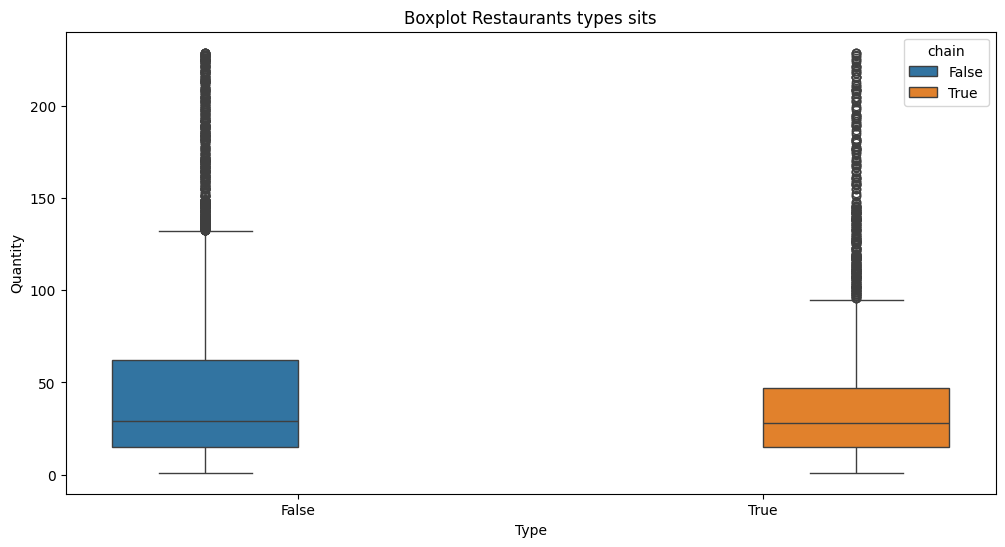

In [35]:
# gráfico boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=is_restaurant, y='number', x='chain', hue='chain')
plt.title('Boxplot Restaurants types sits')
plt.xlabel('Type')
plt.ylabel('Quantity')
plt.show()

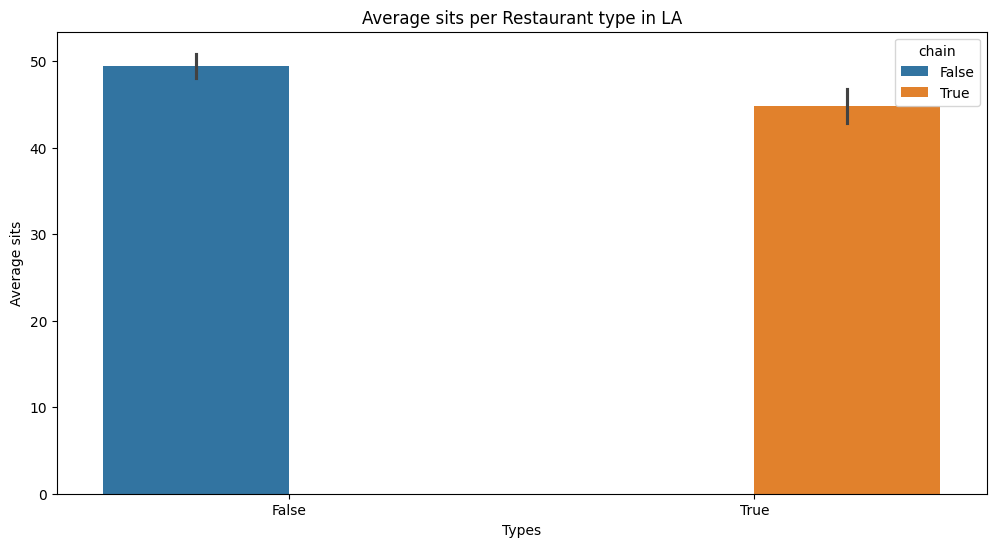

In [36]:
# gráfico barras
plt.figure(figsize=(12,6))
sns.barplot(data=is_restaurant, x='chain', y='number', hue='chain')
plt.title('Average sits per Restaurant type in LA')
plt.xlabel('Types')
plt.ylabel('Average sits')
plt.show()

Os restaurantes que não pertencem a uma rede possuem maior número médio de assentos (46 x 40)

### 3.6 - Coloque os dados dos nomes das ruas da coluna address em uma coluna separada.

In [37]:
# uso de expressão regular para criação de nova coluna
rest_data['street'] = (
    rest_data['address']
    # remoção número inicial
    .str.replace(r'^\d+\s+', '', regex=True)
    # remoção complementos finais
    .str.replace(r'\s+\d+.*$', '', regex=True)
    # remoção espaços em branco
    .str.strip()
)
rest_data['street']

0        n eagle rock blvd
1                world way
2           hollywood blvd
3            w sunset blvd
4            echo park ave
               ...        
9646          w temple ave
9647           melrose ave
9648        hollywood blvd
9649       s spring st ste
9650    s san pedro st ste
Name: street, Length: 9651, dtype: str

### 3.7 - Construa um gráfico de dez ruas com o maior número de restaurantes.

In [38]:
# agrupamento dados
restaurants_per_street = is_restaurant.groupby('address')['name'].count().reset_index().rename(columns={'address': 'address', 'name': 'quantity'}).sort_values('quantity', ascending=False)
streets_with_most_restaurants = restaurants_per_street.iloc[:10]
streets_with_most_restaurants

,address,quantity
4427,5151 state university dr,8
5498,700 world way,7
1916,2025 avenue of the stars,6
4615,545 s figueroa st,6
3677,400 world way,6
2597,300 world way,5
3389,3607 trousdale pkwy,5
4919,600 world way,5
6325,900 w olympic blvd,5
2686,3064 w 8th st,4


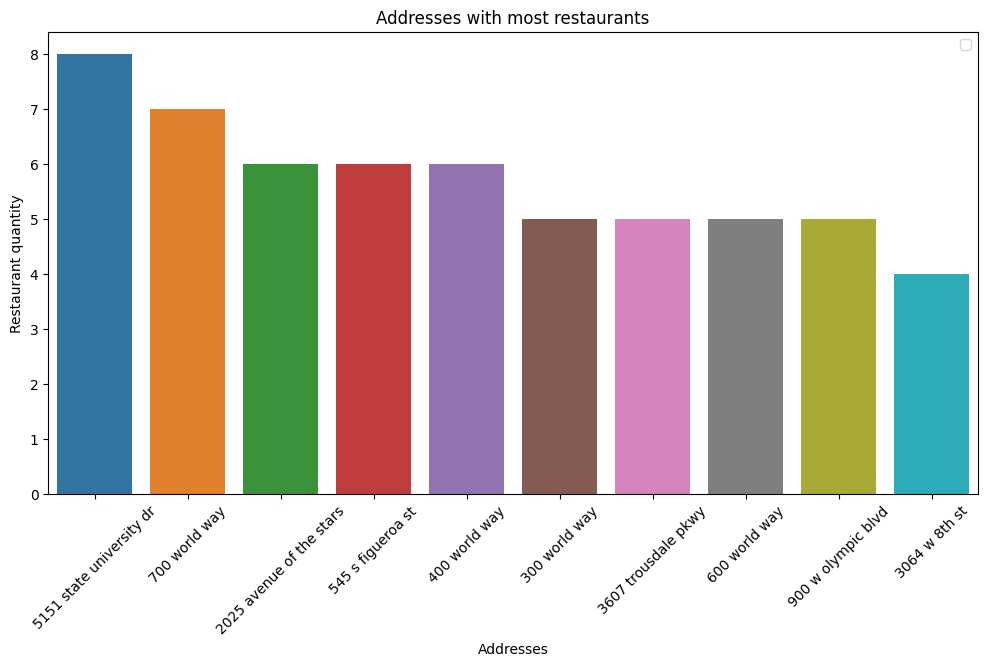

In [39]:
# construção gráfico barras
plt.figure(figsize=(12,6))
sns.barplot(data=streets_with_most_restaurants, x='address', y='quantity', hue='address')
plt.title('Addresses with most restaurants')
plt.xlabel('Addresses')
plt.ylabel('Restaurant quantity')
plt.legend('')
plt.xticks(rotation=45)
plt.show()

5151 State University Dr (8) o ranking de endereços com maior número de restaurantes. Seguido por 700 World Way (7).

Em seguida, 400 World Way, 545 S Figueroa St e 2025 Avenue of the Stars (6).

Finalizando com 300 World Way, 900 W Olympic Blvd, 600 World Way, 3607 Trousdale Pkwy (5) e 6360 W Sunset Blvd (4)


### 3.8 - Encontre o número de ruas que têm apenas um restaurante.

In [40]:
# agrupamento dados
streets_with_one_restaurant = restaurants_per_street[restaurants_per_street['quantity'] == 1]
streets_with_one_restaurant
print(f'Existem {streets_with_one_restaurant.shape[0]} ruas com apenas um restaurante.')

Existem 5893 ruas com apenas um restaurante.


Foram encontradas 5893 ruas em LA com apenas um restaurante.


### 3.9 - Para as ruas com muitos restaurantes, olhe para a distribuição de número de assentos. Quais tendências você consegue notar?

In [41]:
# filtro dados
popular_addresses = streets_with_most_restaurants['address']
popular_addresses = is_restaurant[is_restaurant['address'].isin(popular_addresses)]
popular_addresses

,id,name,address,chain,type,number
19,11805,delta sky club t3,300 world way,False,restaurant,103
46,11832,the counter space 7c,700 world way,True,restaurant,20
56,11842,loteria grill space 7c,700 world way,False,restaurant,17
62,11848,rolling stone space 7c,700 world way,False,restaurant,33
107,11893,admirals club,400 world way,False,restaurant,118
457,12243,usc main kitchen-basement,3607 trousdale pkwy,True,restaurant,227
462,12248,traditions pub,3607 trousdale pkwy,False,restaurant,197
576,12362,jonathan club-bake shop,545 s figueroa st,False,restaurant,5
579,12365,jonathan club cape code,545 s figueroa st,False,restaurant,64
581,12367,employee cafeteria,545 s figueroa st,True,restaurant,33


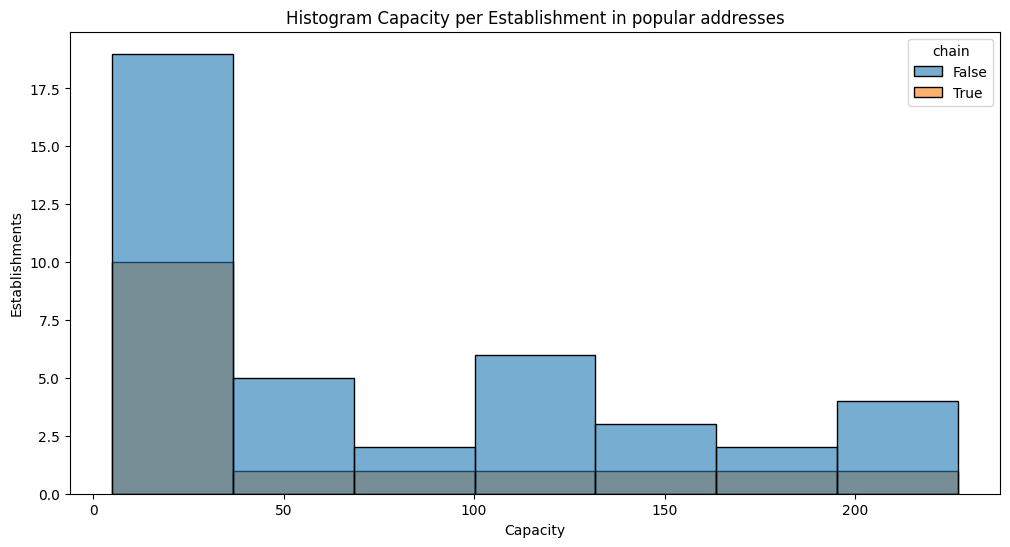

In [42]:
# construção gráfico linhas
plt.figure(figsize=(12,6))
sns.histplot(data=popular_addresses, x='number', hue='chain', alpha=0.6)
plt.title('Histogram Capacity per Establishment in popular addresses')
plt.xlabel('Capacity')
plt.ylabel('Establishments')
plt.show()

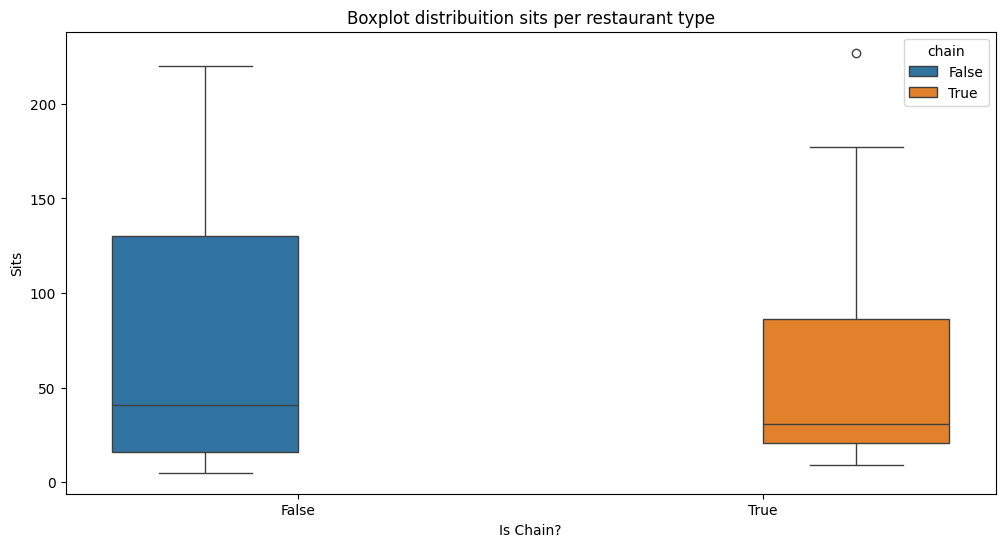

In [43]:
# construção boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=popular_addresses, y='number', x='chain', hue='chain')
plt.title('Boxplot distribuition sits per restaurant type')
plt.xlabel('Is Chain?')
plt.ylabel('Sits')
plt.show()

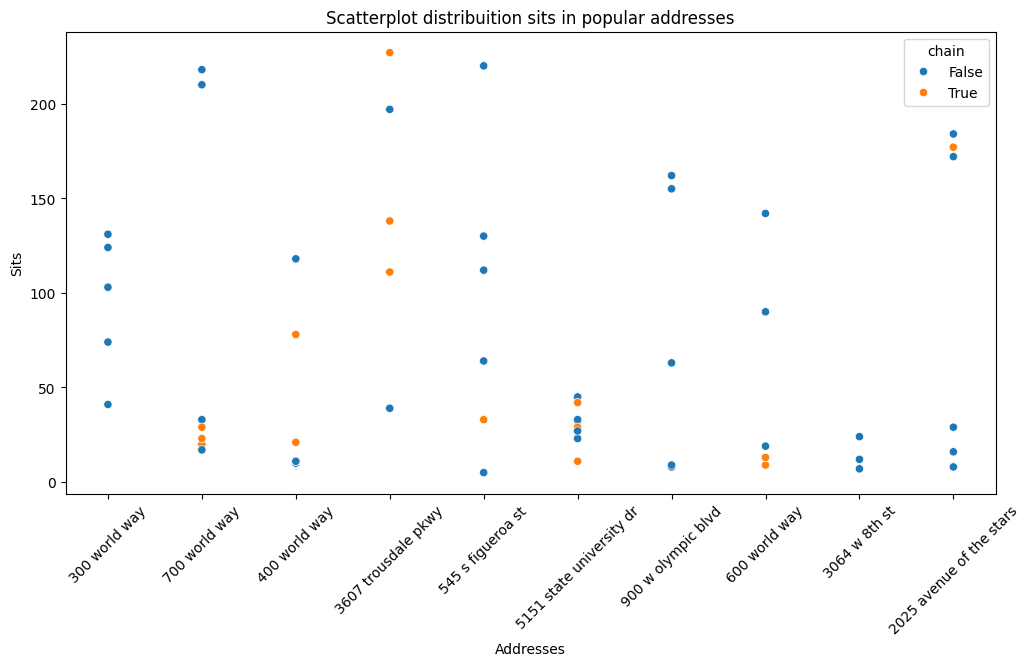

In [44]:
# construção boxplot
plt.figure(figsize=(12,6))
sns.scatterplot(data=popular_addresses, x='address', y='number', hue='chain')
plt.title('Scatterplot distribuition sits in popular addresses')
plt.xlabel('Addresses')
plt.ylabel('Sits')
plt.xticks(rotation=45)
plt.show()

A maior parte destes restaurantes tendem a possuir capacidade pequena.

Restaurantes que não fazem parte de uma rede tendem a possuir maior de capacidade.


## 4. - Conclusão

### 4.1 - Tire uma conclusão geral e apresente recomendações sobre o tipo mais apropriado de restaurante e o número de assentos. Comente sobre a possibilidade de desenvolver uma rede.

A análise do mercado de restaurantes em Los Angeles indica que o setor é altamente competitivo, com forte concentração no segmento de restaurantes tradicionais, enquanto cafés representam uma fatia menor (4.5%). Observa-se que estabelecimentos pertencentes a redes tendem a operar com menor número de assentos, enquanto negócios independentes concentram-se em operações maiores.

A decisão pela abertura de um Café significa enfrentar concorrência relativamente inferior se comparada aos outros tipos de estabelecimento, o que é completamente plausível por se tratar de um projeto piloto. Em tese, um estabelecimento operado por robôs pode parecer mais eficiente, contudo apenas a experiência que pode validar esta máxima. Para menor margem de erros, recomenda-se trabalhar numa operação mais simples e enxuta, com preferência a um menor número de assentos.
A possibilidade do desenvolvimento de uma rede passa diretamente pelo sucesso da primeira unidade, o que pode ser uma ótima maneira de escalar a ideia de negócio.